In [2]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Oscillations and stable up and down

In [3]:
aln = ALNModel()
N = aln.params.N
aln.params.dt = .1

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [4]:
aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

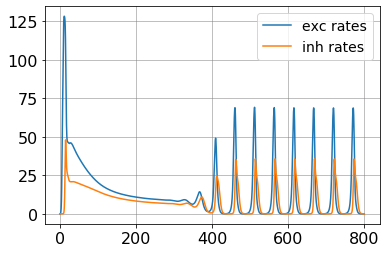

In [5]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

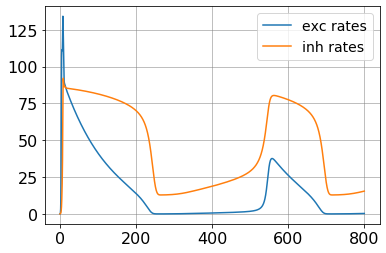

In [6]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

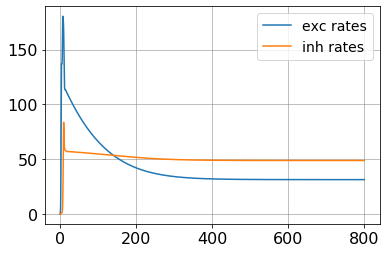

[31.3076 48.768 ]


In [7]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

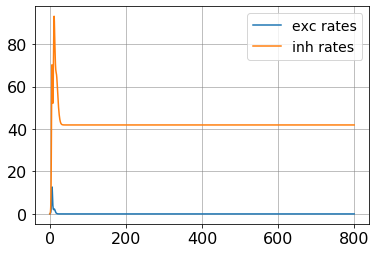

[4.4580e-10 4.1918e+01]


In [8]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

# A: Scenarios

scenario | control variables | precision measure
---------|--------------|-----------
A.0 | 0 | 0
B.1 | 1 | 1
B.2 | 2 | 0
B.3 | 0 | 1
B.4 | 1 | 0
B.5 | 2 | 1
B.6 | 0, 1 | 0
B.7 | 0, 1 | 1
B.8 | 0, 2 | 0
B.9 | 0, 2 | 1
B.10 | 1, 2 | 0
B.11 | 1, 2 | 1
B.12 | 0, 1, 2 | 0
B.13 | 0, 1, 2 | 1
B.14 | 0 | 0,1
B.15 | 1 | 0,1
B.16 | 2 | 0,1
B.17 | 0,1 | 0,1
B.18 | 0,2 | 0,1
B.19 | 1,2 | 0,1
B.20 | 0,1,2 | 0,1

In [9]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 5000
set_params_fast()
initVars = fast_osc_init

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

trans_time_array = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 
                    0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5 ]

sheet = "C_a_"

target_rates = np.array( [down_rates[0], down_rates[1]])

In [14]:
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
    elif cntrl_vars == [1]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [2]:
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
            
    return max_cntrl, min_cntrl        

In [11]:
# B.0.a)

dur = 300
dur_pre = 100
dur_post = 100
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

## 0

In [ ]:
case_ind = 0
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

In [15]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case_ind = 0
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

max_it = 100

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params


NameError: name 'max_cntrl' is not defined

## 2

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40765.013021201754
RUN  1 , total integrated cost =  39655.63458712966
RUN  2 , total integrated cost =  33464.84675391956
RUN  3 , total integrated cost =  22956.65704081059
RUN  4 , total integrated cost =  22942.78536031837
RUN  5 , total integrated cost =  22281.16216708499
RUN  6 , total integrated cost =  22217.724792842342
RUN  7 , total integrated cost =  22217.695895458586
RUN  8 , total integrated cost =  22217.69530996704
RUN  9 , total integrated cost =  22217.69509756241
RUN  10 , total integrated cost =  22217.497464890042
RUN  11 , total integrated cost =  22217.149680890136
RUN  12 , total integrated cost =  22217.001549912457
RUN  13 , total integrated cost =  22217.00106149528
RUN  14 , total integrated cost =  22216.676886388253
RUN  15 , total integrated cost =  22216.33351282046
RUN  16 , total integrated cost =  22216.332566704605
R

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  149 , total integrated cost =  15239.758593879984
Improved over  149  iterations by  62.615592478889106  percent.
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.25632976272693
Problem in initial value trasfer:  Vmean_exc -57.064446596300556 -57.03972417691069


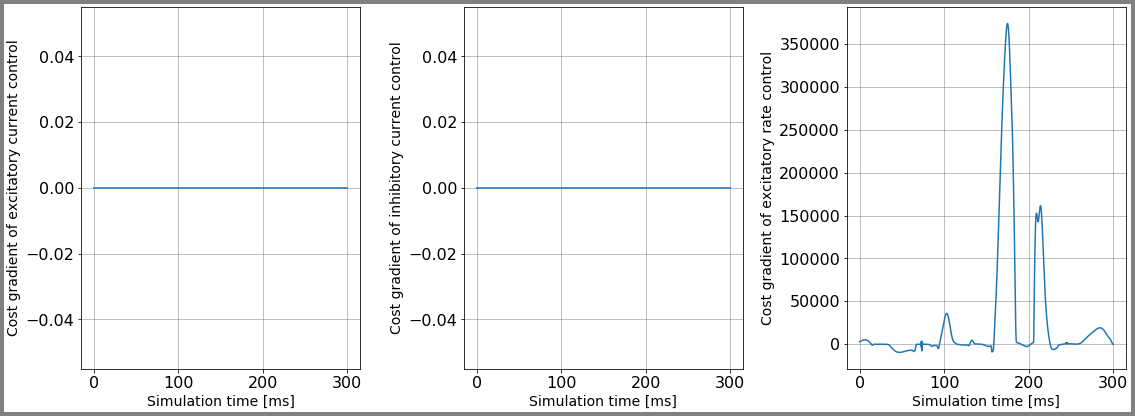

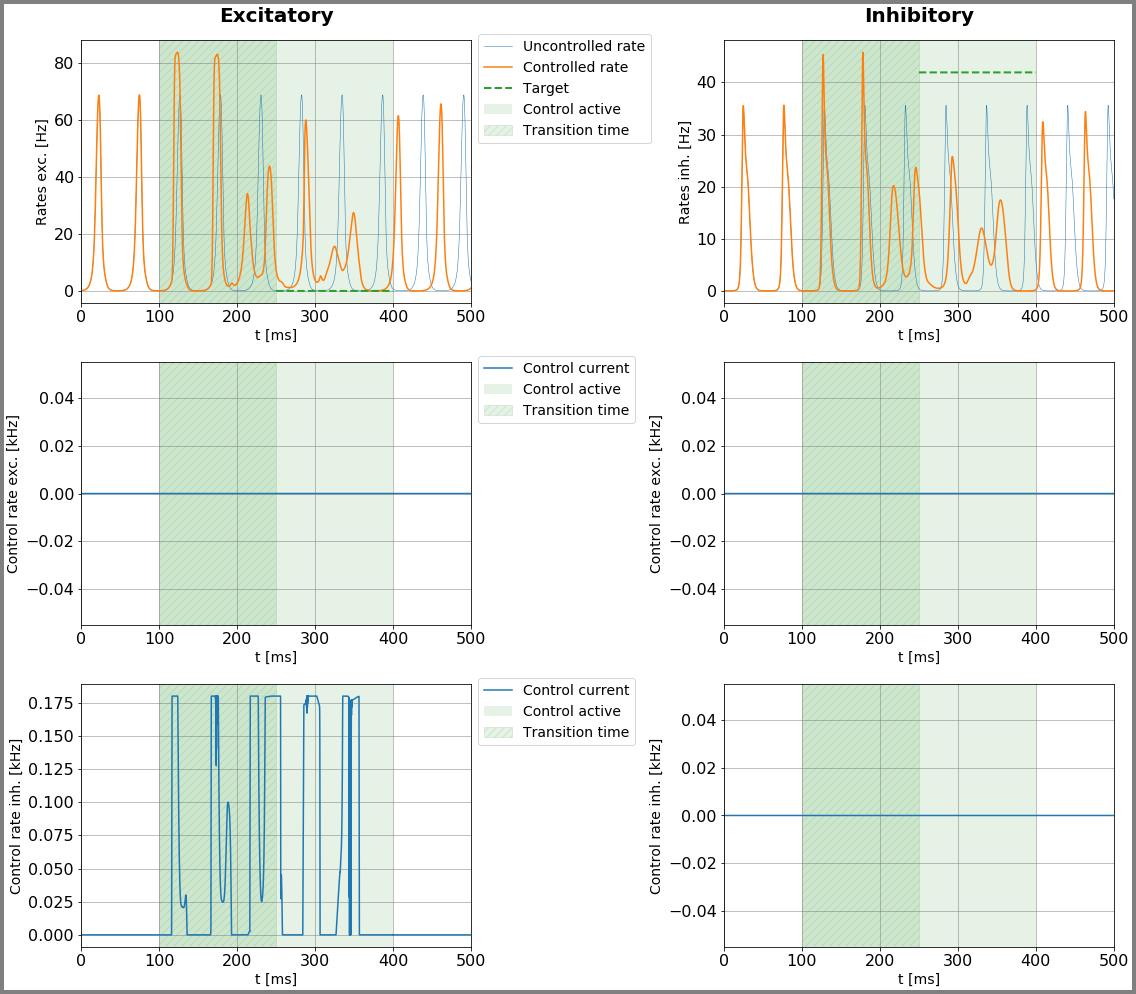

In [13]:
case_ind = 2
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40765.013021201754
RUN  1 , total integrated cost =  39655.806759018225
RUN  2 , total integrated cost =  33519.6217630055
RUN  3 , total integrated cost =  32452.96114878123
RUN  4 , total integrated cost =  32452.96114878123


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  4 , total integrated cost =  32452.96114878123
Improved over  4  iterations by  20.39016121029435  percent.
Problem in initial value trasfer:  sigmae_f 1.560808398485069 1.5607976665855507
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.25632859690785
Problem in initial value trasfer:  tau_exc 19.346655582108767 19.346758216952615
Problem in initial value trasfer:  Vmean_exc -56.76289469885227 -56.76385513496146


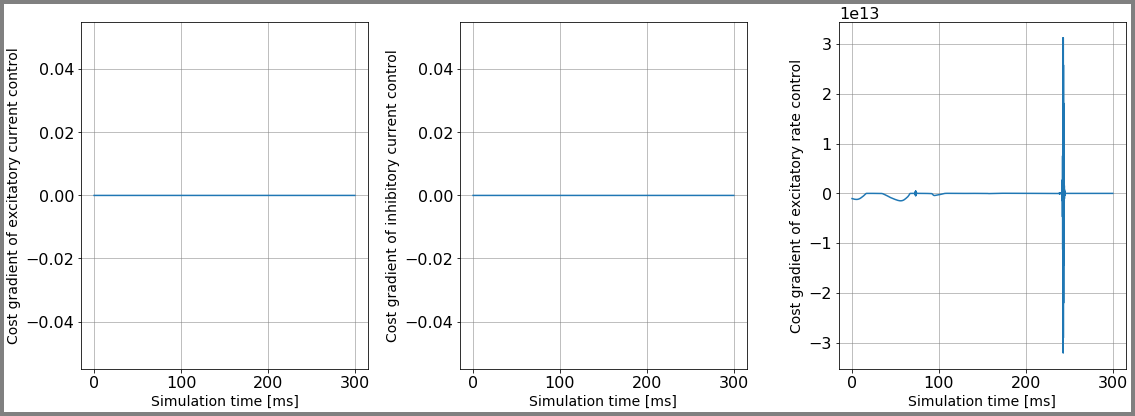

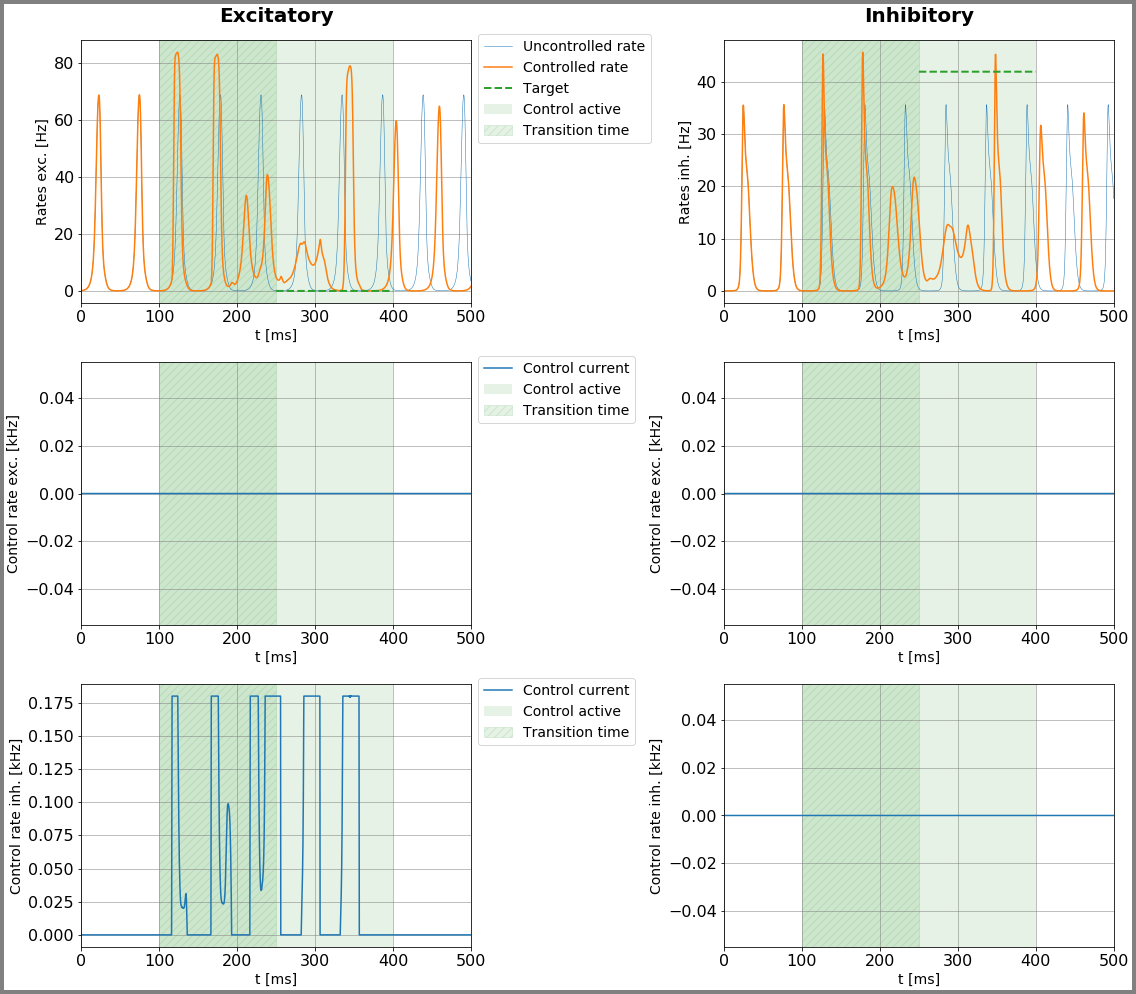

In [14]:
case_ind = 2
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 4

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40765.013021201754
RUN  1 , total integrated cost =  10654.874046374109
RUN  2 , total integrated cost =  0.005407339690895372
RUN  3 , total integrated cost =  0.0026723883031439673
RUN  4 , total integrated cost =  0.0017941247810443527
RUN  5 , total integrated cost =  0.0007468849132482603
RUN  6 , total integrated cost =  8.277188023645859e-08
RUN  7 , total integrated cost =  1.459588684837322e-17
RUN  8 , total integrated cost =  1.4176977407752118e-17
RUN  9 , total integrated cost =  1.4110514413256253e-17
RUN  10 , total integrated cost =  1.410100337363643e-17
RUN  11 , total integrated cost =  1.4086185392198473e-17
RUN  12 , total integrated cost =  1.4080413964060878e-17
RUN  13 , total integrated cost =  1.406199231863029e-17
RUN  14 , total integrated cost =  1.4055410783105923e-17
RUN  15 , total integrated cost =  1.3943494482656702e-17

ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  1.0464294652361493e-17
RUN  5000 , total integrated cost =  1.0464294652361493e-17
Improved over  5000  iterations by  100.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.25632976272693


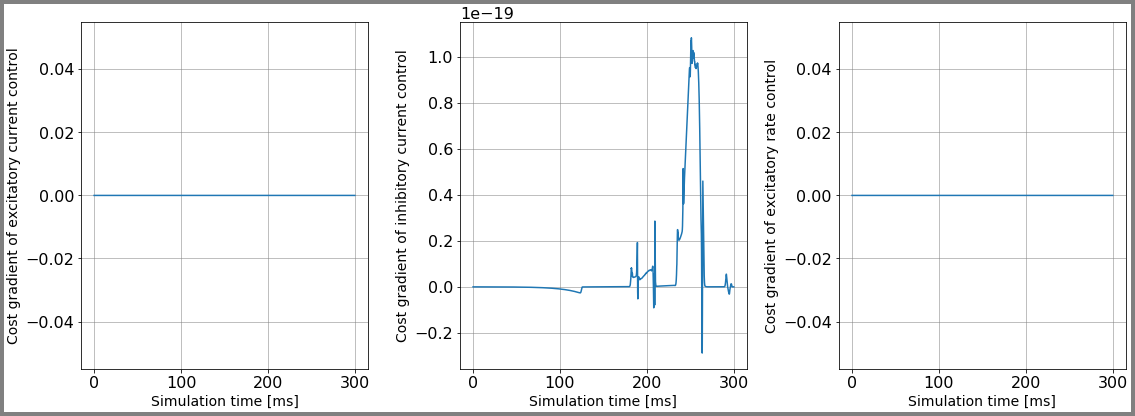

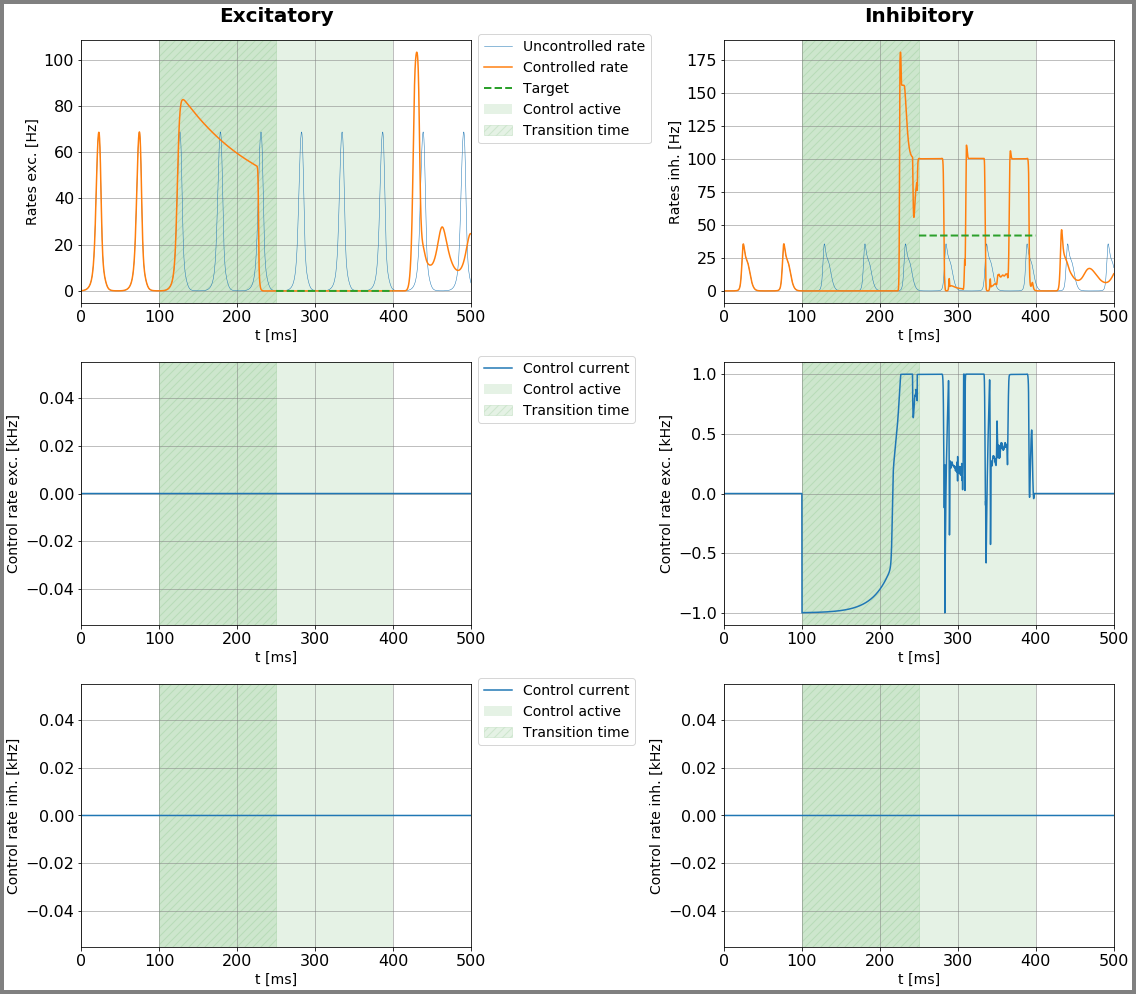

In [15]:
# A.4.a)

case_ind = 4
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40765.013021201754
RUN  1 , total integrated cost =  10751.430688014934
RUN  2 , total integrated cost =  4761.648051863947
RUN  3 , total integrated cost =  3696.608379589699
RUN  4 , total integrated cost =  2856.460994753606
RUN  5 , total integrated cost =  2525.554469068652
RUN  6 , total integrated cost =  2013.0709966984678
RUN  7 , total integrated cost =  1817.8095286043476
RUN  8 , total integrated cost =  1650.9294733999707
RUN  9 , total integrated cost =  1553.365027554954
RUN  10 , total integrated cost =  1481.5435758947176
RUN  11 , total integrated cost =  1421.4360068712317
RUN  12 , total integrated cost =  1378.6375928706846
RUN  13 , total integrated cost =  1338.063497075561
RUN  14 , total integrated cost =  1330.1934568677389
RUN  15 , total integrated cost =  1322.4117573629774
RUN  16 , total integrated cost =  1315.8346849917327
RUN  17 , total integrated cost =  1308.9366

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  1003.1240577503106
RUN  5000 , total integrated cost =  1003.1240577503106
Improved over  5000  iterations by  97.53925245349832  percent.
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.25632976272693
Problem in initial value trasfer:  Vmean_exc -58.67098043944574 -58.62108776837877


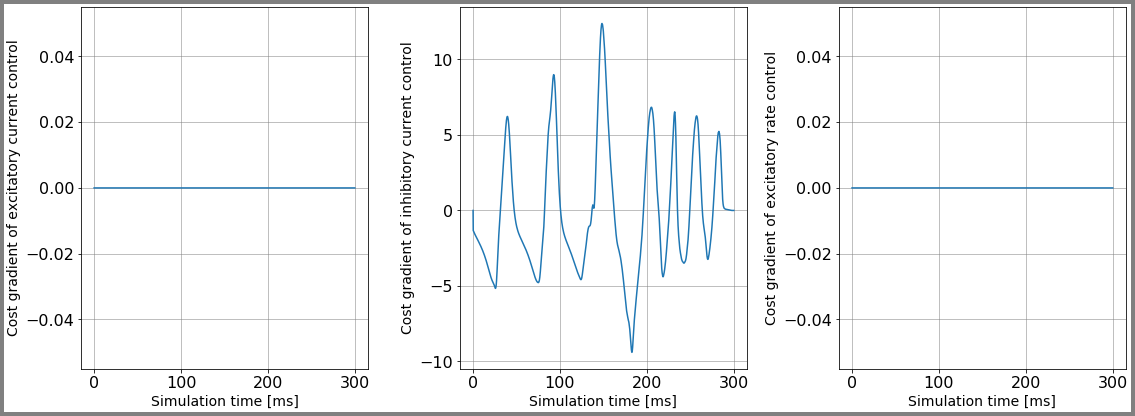

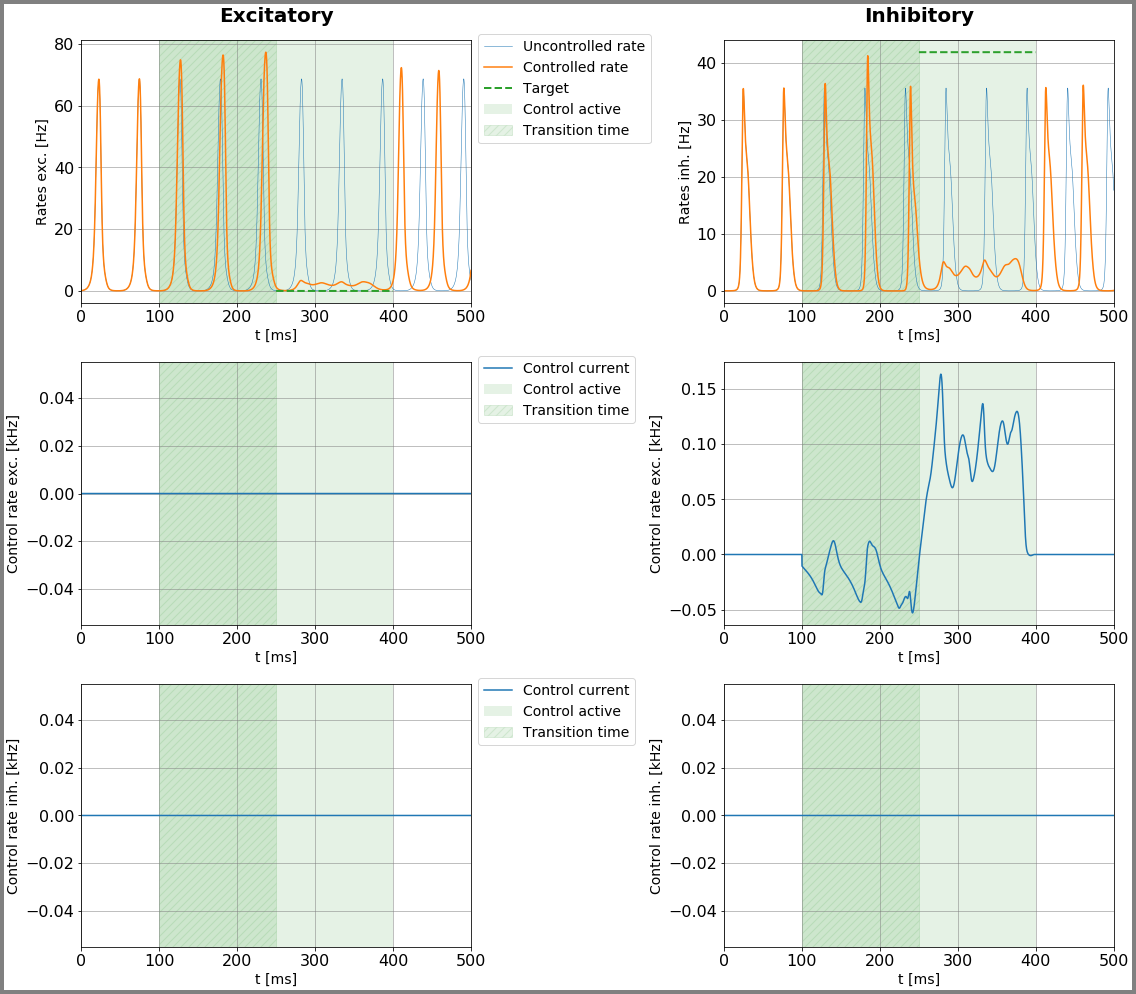

In [16]:
case_ind = 4
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 6

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40765.013021201754
RUN  1 , total integrated cost =  5307.355348607281
RUN  2 , total integrated cost =  1.4767268810166812e-17
RUN  3 , total integrated cost =  1.4689579559928163e-17
RUN  4 , total integrated cost =  1.468948658585205e-17
RUN  5 , total integrated cost =  1.4689485701514878e-17
RUN  6 , total integrated cost =  1.468948567992956e-17
RUN  7 , total integrated cost =  1.4689485679556102e-17
RUN  8 , total integrated cost =  1.468948567955454e-17
RUN  9 , total integrated cost =  1.4689485679554478e-17


ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  1.4689485679554478e-17
Control only changes marginally.
RUN  10 , total integrated cost =  1.4689485679554478e-17
Improved over  10  iterations by  100.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.25632976272693


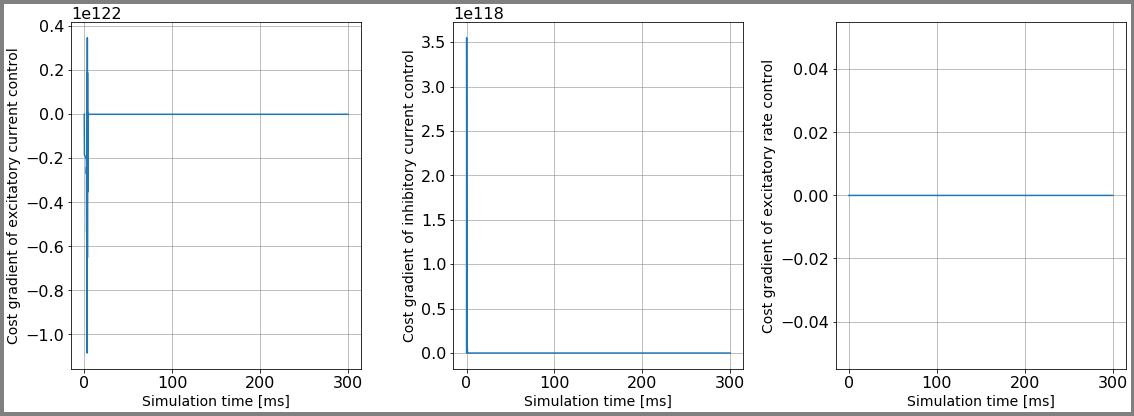

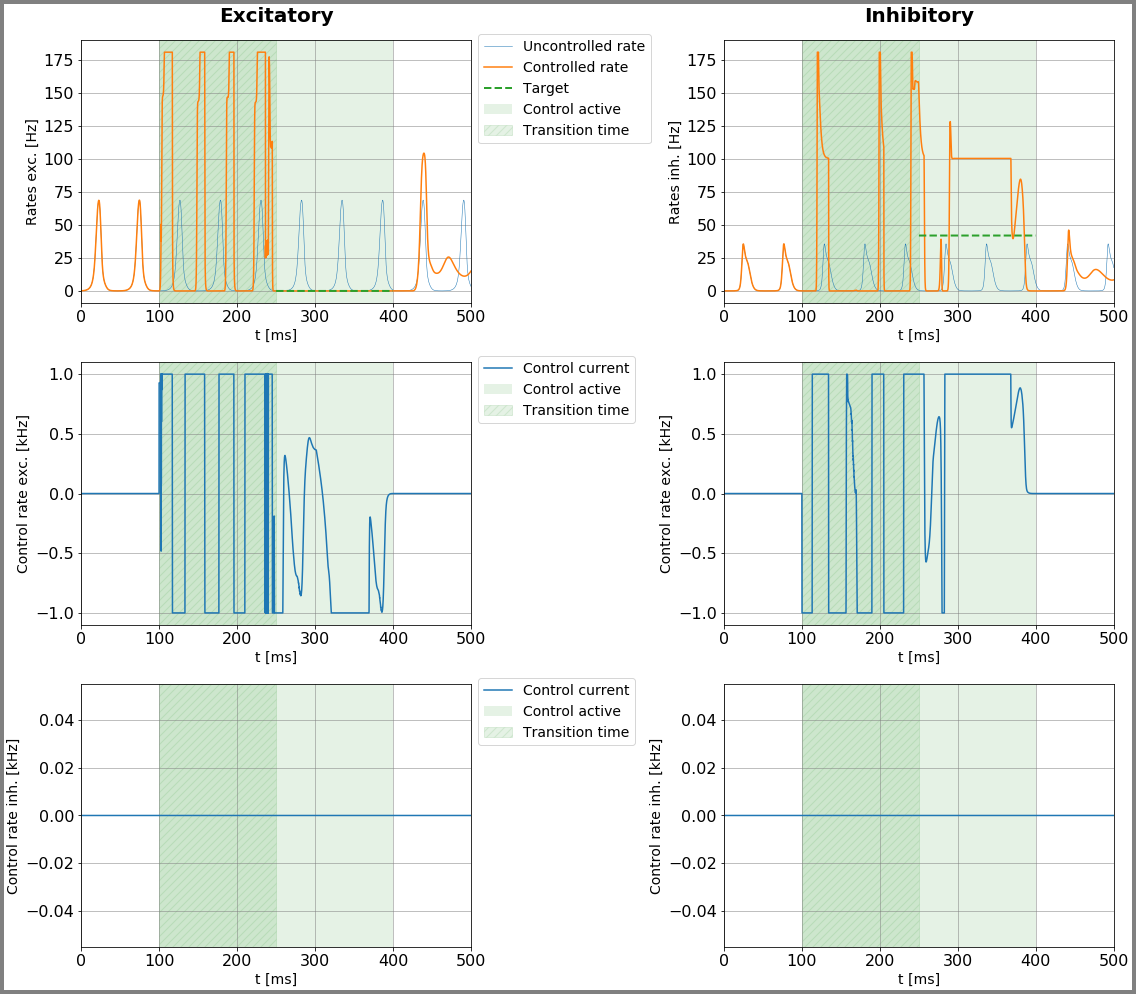

In [17]:
# A.6.a)
case_ind = 6
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40765.013021201754
RUN  1 , total integrated cost =  10751.430688014934
RUN  2 , total integrated cost =  3727.7244779573834
RUN  3 , total integrated cost =  3450.3303381210417
RUN  4 , total integrated cost =  2322.892341204184
RUN  5 , total integrated cost =  1847.1549418553088
RUN  6 , total integrated cost =  1700.568115448043
RUN  7 , total integrated cost =  1634.2980495889497
RUN  8 , total integrated cost =  1566.7827318231189
RUN  9 , total integrated cost =  1524.7999409094714
RUN  10 , total integrated cost =  1484.5323038939773
RUN  11 , total integrated cost =  1455.078928861715
RUN  12 , total integrated cost =  1430.3262747254519
RUN  13 , total integrated cost =  1409.4622685200443
RUN  14 , total integrated cost =  1391.576553039015
RUN  15 , total integrated cost =  1375.4018675025295
RUN  16 , total integrated cost =  1360.0176299548643
RUN  17 , total integrated cost =  1344.95

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  758.5236481732884
RUN  5000 , total integrated cost =  758.5236481732884
Improved over  5000  iterations by  98.13927779741225  percent.
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.25632976272693
Problem in initial value trasfer:  Vmean_exc -58.578915200588234 -58.52053949545494


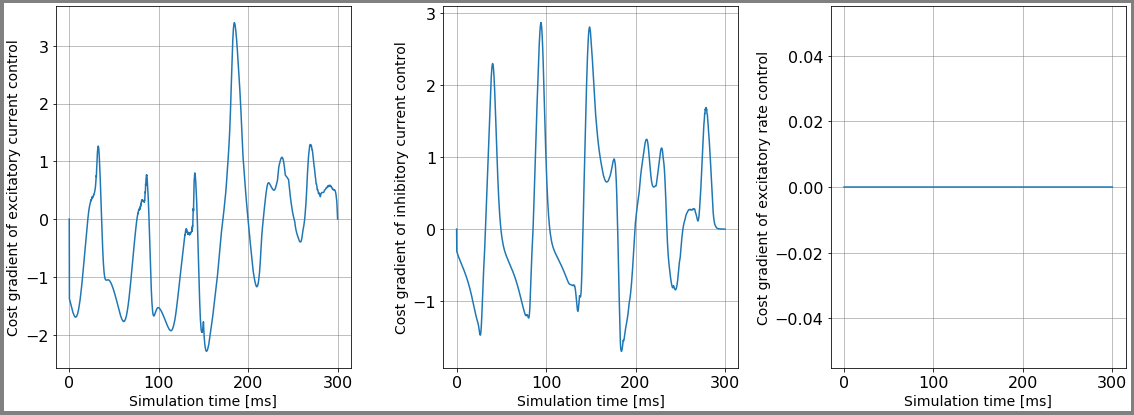

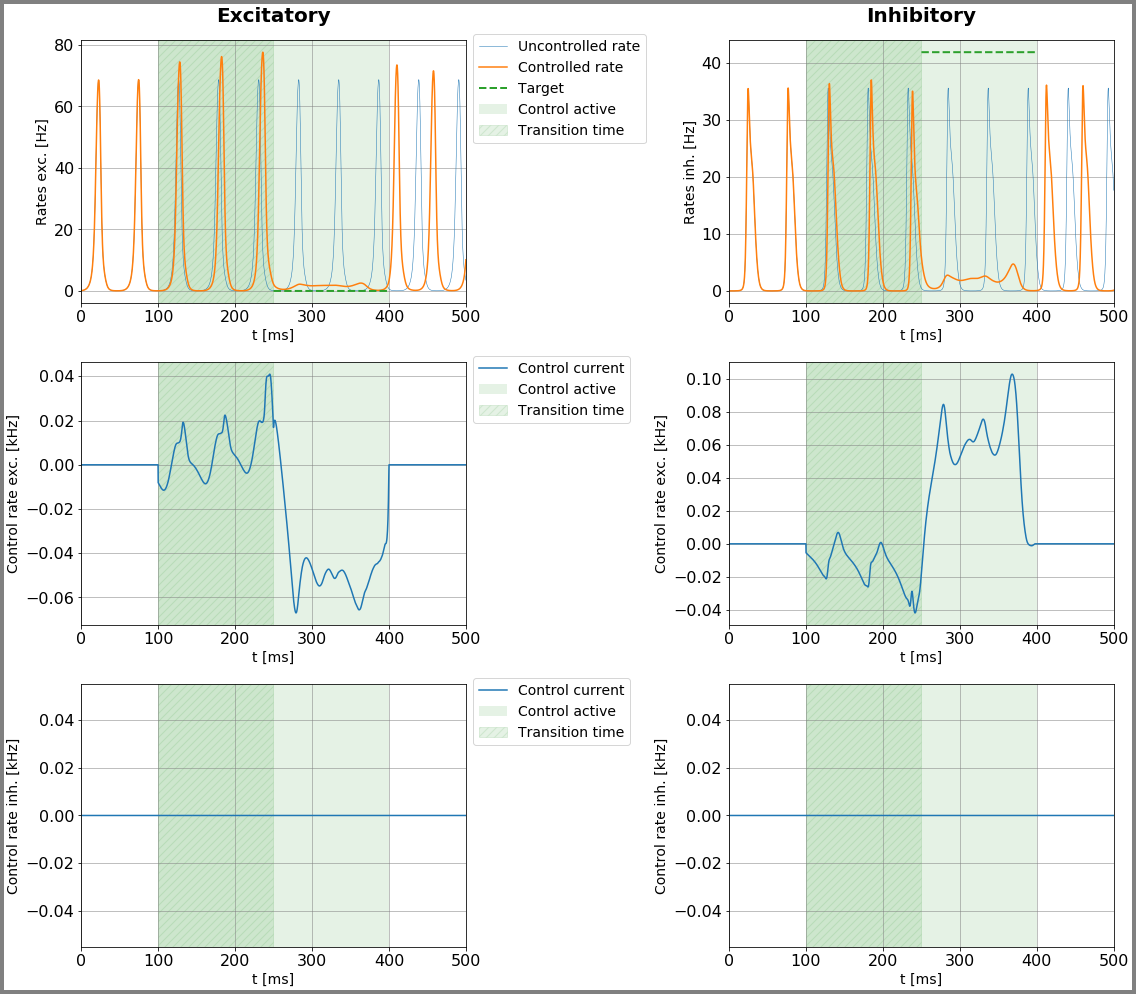

In [18]:
case_ind = 6
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 8

set cost params
control input:  [0, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40765.013021201754
RUN  1 , total integrated cost =  1.4853470556590137e-17
RUN  2 , total integrated cost =  1.4853469752256594e-17
RUN  3 , total integrated cost =  1.4853469662344826e-17
RUN  4 , total integrated cost =  1.4853469644357725e-17
RUN  5 , total integrated cost =  1.4853469633183963e-17
RUN  6 , total integrated cost =  1.485346963318379e-17


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  1.485346963318379e-17
Control only changes marginally.
RUN  7 , total integrated cost =  1.485346963318379e-17
Improved over  7  iterations by  100.0  percent.
Problem in initial value trasfer:  sigmae_f 1.560808398485069 1.5554816784522252
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.2557511139906
Problem in initial value trasfer:  tau_exc 19.346655582108767 19.397597829365015


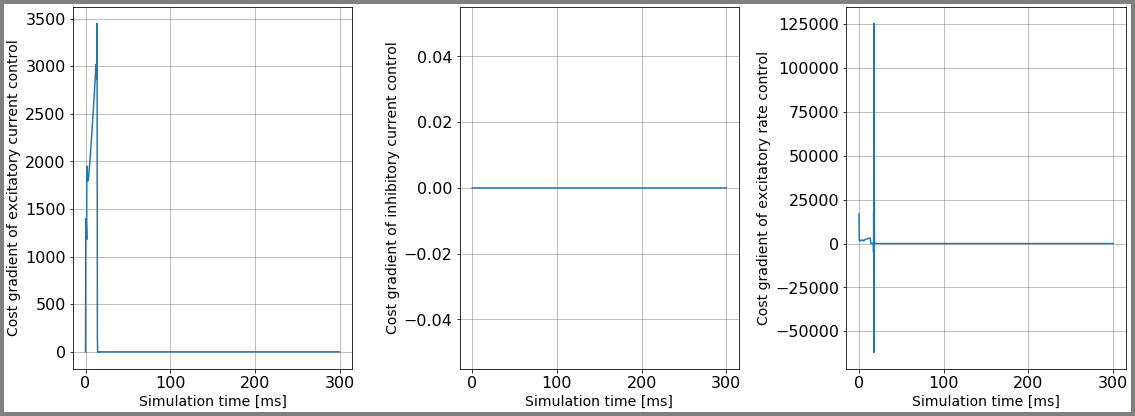

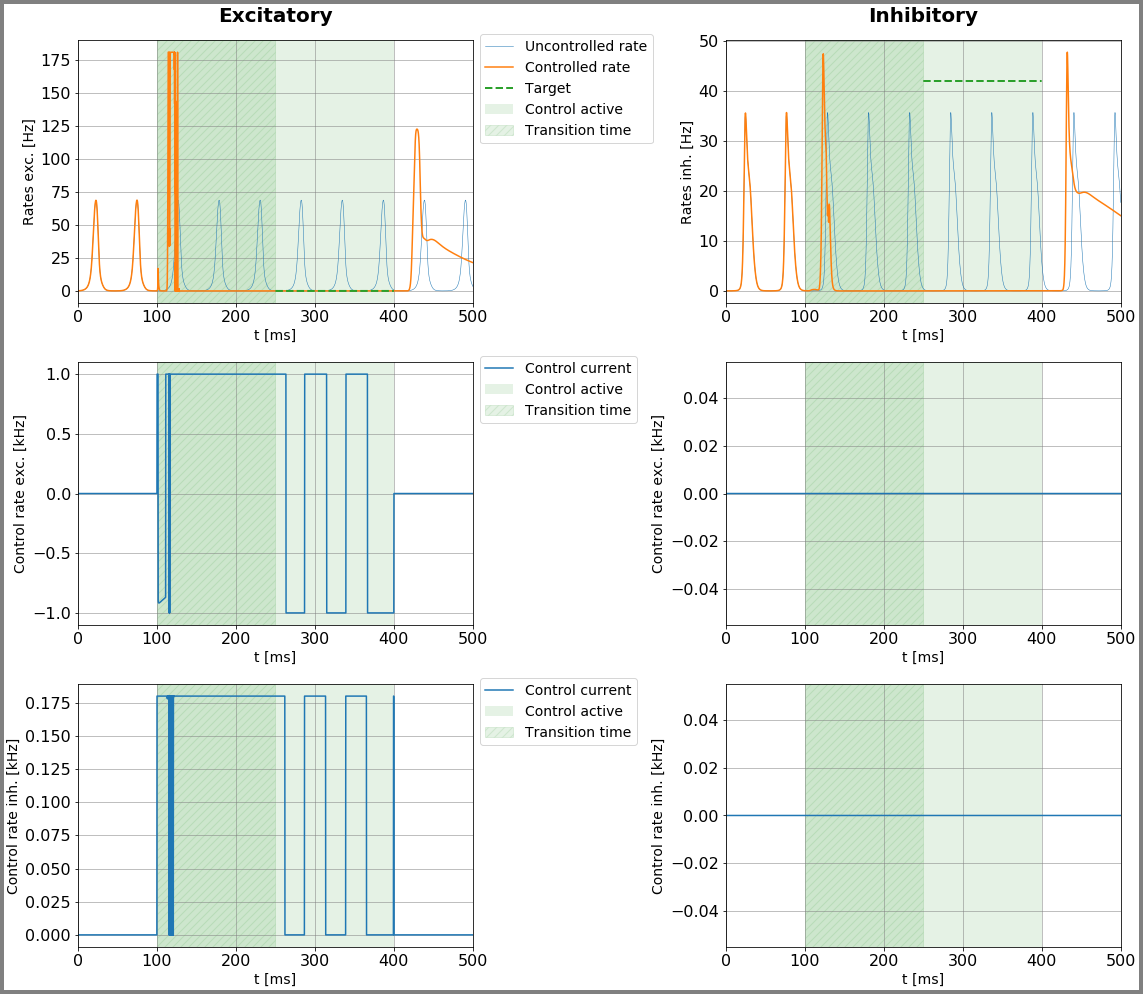

In [19]:
# A.8.a)
case_ind = 8
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40765.013021201754
RUN  1 , total integrated cost =  24344.99964434675
RUN  2 , total integrated cost =  16292.398041302617
RUN  3 , total integrated cost =  16208.180334360872
RUN  4 , total integrated cost =  16135.59734954008
RUN  5 , total integrated cost =  16034.63954478652
RUN  6 , total integrated cost =  15946.91347466066
RUN  7 , total integrated cost =  15844.396912324119
RUN  8 , total integrated cost =  15759.396700168463
RUN  9 , total integrated cost =  15608.540979646952
RUN  10 , total integrated cost =  15493.815453855254
RUN  11 , total integrated cost =  13603.423611536911
RUN  12 , total integrated cost =  11668.445306888992
RUN  13 , total integrated cost =  11643.949714209524
RUN  14 , total integrated cost =  11623.788580289856
RUN  15 , total integrated cost =  11576.678817007913
RUN  16 , total integrated cost =  11540.55885818744
RUN  17 , total integrated cost =  11486.01

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  3141.5631226716173
RUN  5000 , total integrated cost =  3141.5631226716173
Improved over  5000  iterations by  92.2934818614244  percent.
Problem in initial value trasfer:  sigmae_f 1.560808398485069 1.5584524422659851
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.25607383204604
Problem in initial value trasfer:  tau_exc 19.346655582108767 19.36918684027467
Problem in initial value trasfer:  Vmean_exc -58.60613690940708 -58.56192661787789


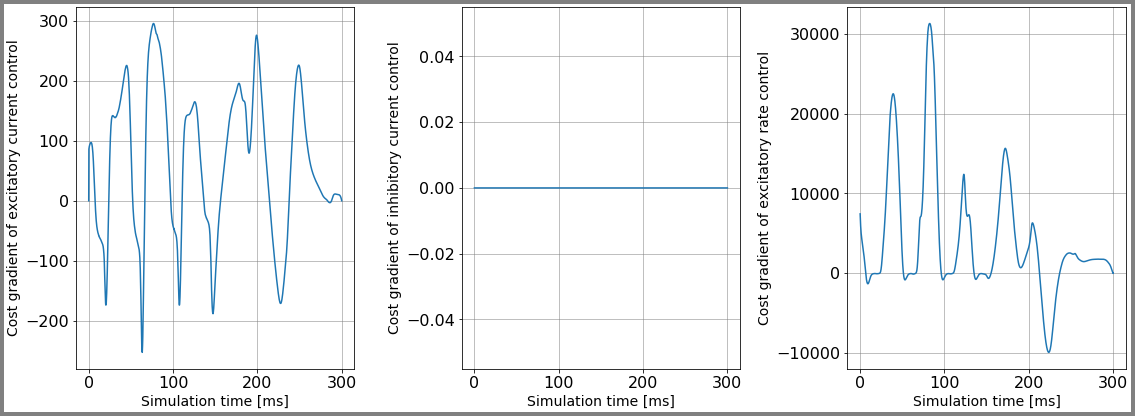

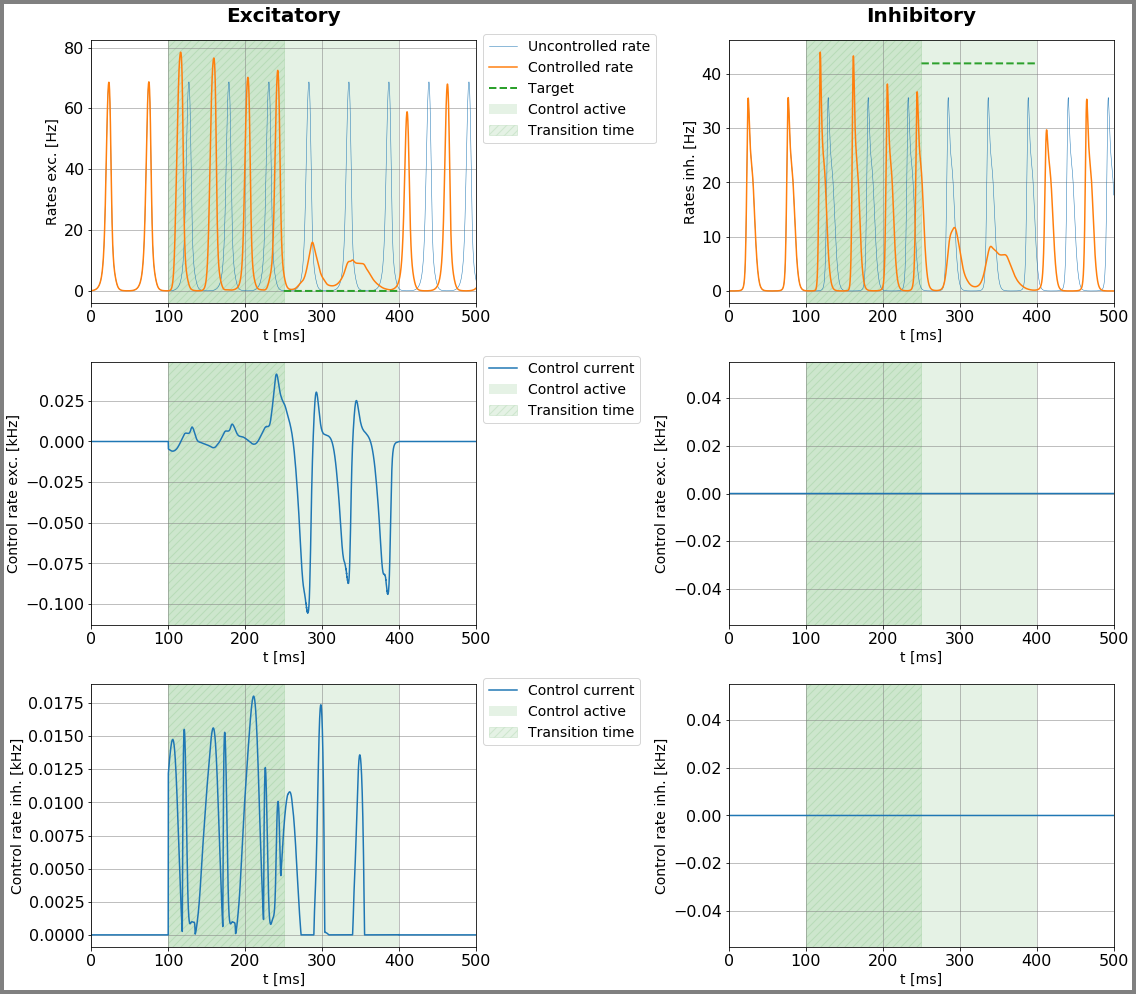

In [20]:
case_ind = 8
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 10

set cost params
control input:  [1, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40765.013021201754
RUN  1 , total integrated cost =  10654.874046374109
RUN  2 , total integrated cost =  0.0013904927118716858
 max iteration reached, step size =  6.109872726999209e-150
 max iteration reached, step size =  6.109872726999209e-150
RUN  3 , total integrated cost =  0.0012922204504203108
RUN  4 , total integrated cost =  0.00011656133506322181
RUN  5 , total integrated cost =  1.2399892972639128e-06
RUN  6 , total integrated cost =  2.5995492855512557e-07
RUN  7 , total integrated cost =  5.004417690696283e-08
RUN  8 , total integrated cost =  9.260048300818724e-10
RUN  9 , total integrated cost =  5.163605129576805e-10
RUN  10 , total integrated cost =  9.763724769136644e-11
RUN  11 , total integrated cost =  4.893394478688743e-11
RUN  12 , total integrated cost =  3.266438227969461e-11
RUN  13 , total integrated cost =  1.620081064560

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  16 , total integrated cost =  2.329934631602784e-12
Control only changes marginally.
RUN  16 , total integrated cost =  2.329934631602784e-12
Improved over  16  iterations by  100.0  percent.
Problem in initial value trasfer:  sigmae_f 1.560808398485069 1.5554816784522252
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.2557511139906
Problem in initial value trasfer:  tau_exc 19.346655582108767 19.397597829365015


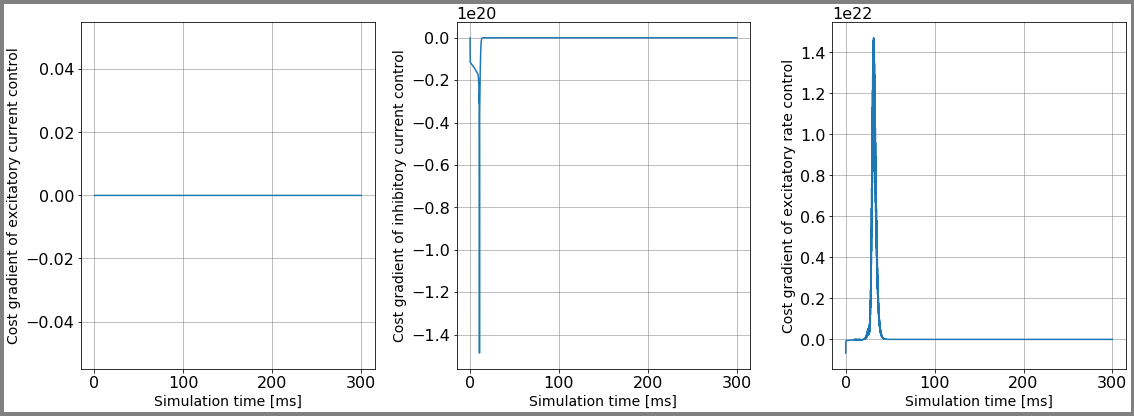

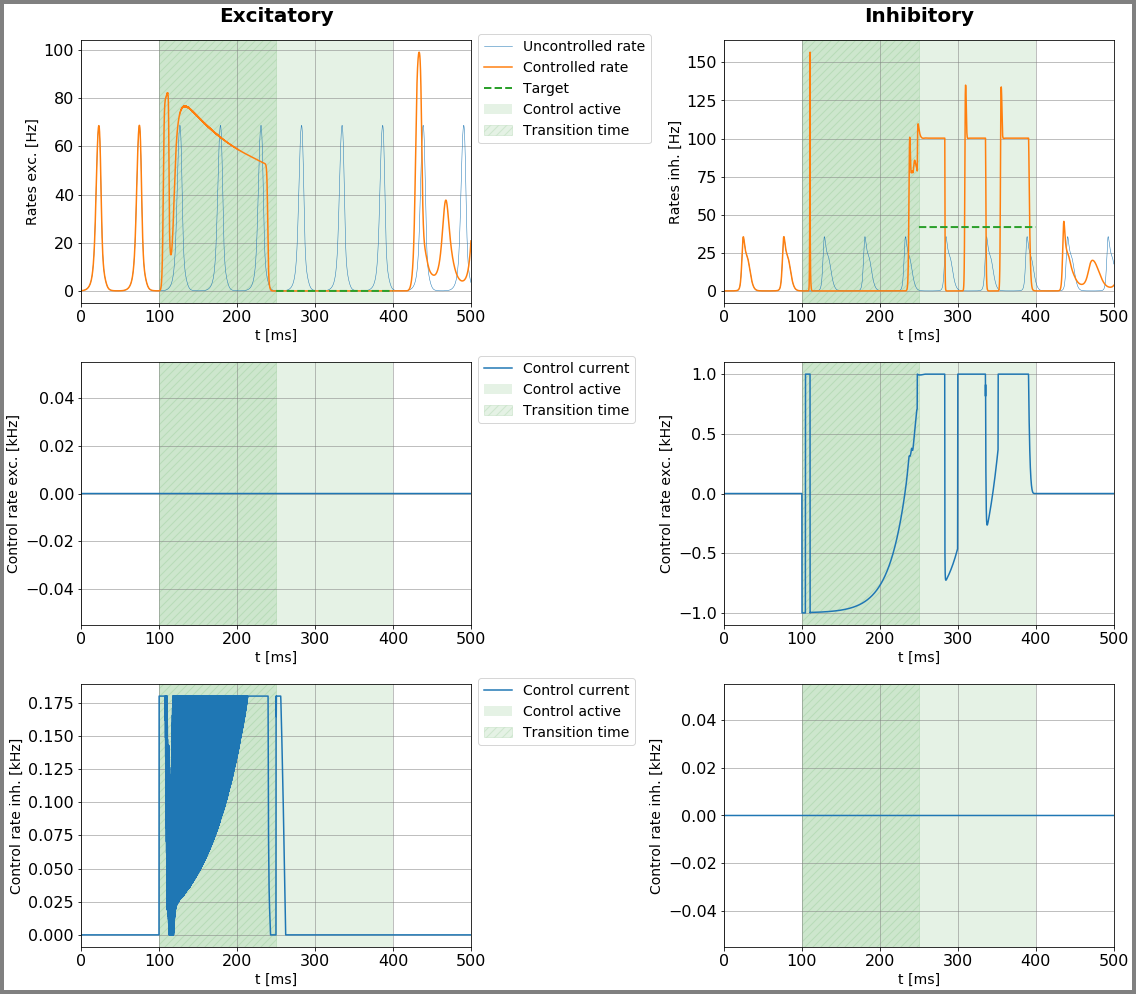

In [21]:
# A.10.a)
case_ind = 10
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40765.013021201754
RUN  1 , total integrated cost =  10751.430688014934
RUN  2 , total integrated cost =  4761.648051863947
RUN  3 , total integrated cost =  3585.6805156045702
RUN  4 , total integrated cost =  3418.0907413098944
RUN  5 , total integrated cost =  3417.5159807334476
RUN  6 , total integrated cost =  3415.106235714498
RUN  7 , total integrated cost =  3411.0231666926134
RUN  8 , total integrated cost =  1481.573336781245
RUN  9 , total integrated cost =  1345.884858447917
RUN  10 , total integrated cost =  1316.589353097447
RUN  11 , total integrated cost =  1297.5971379660473
RUN  12 , total integrated cost =  1281.065094233483
RUN  13 , total integrated cost =  1271.5118484597203
RUN  14 , total integrated cost =  1252.909979816724
RUN  15 , total integrated cost =  1252.8455081079487
RUN  16 , total integrated cost =  1252.8455081079453
RUN  17 , total integrated cost =  1252.84550

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  1252.8455081079444
Control only changes marginally.
RUN  19 , total integrated cost =  1252.8455081079444
Improved over  19  iterations by  96.92666476653315  percent.
Problem in initial value trasfer:  sigmae_f 1.560808398485069 1.5554816784522252
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.2557511139906
Problem in initial value trasfer:  tau_exc 19.346655582108767 19.397597829365015
Problem in initial value trasfer:  Vmean_exc -62.365186029578716 -62.309406086986314


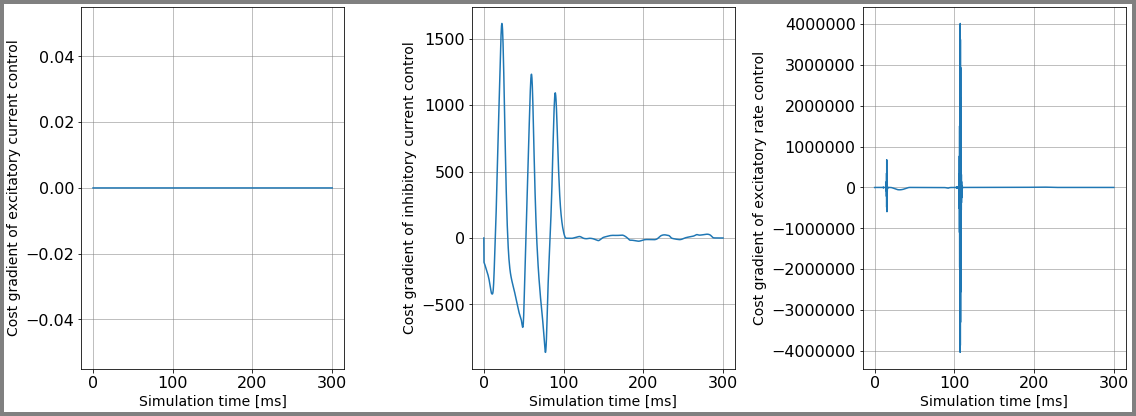

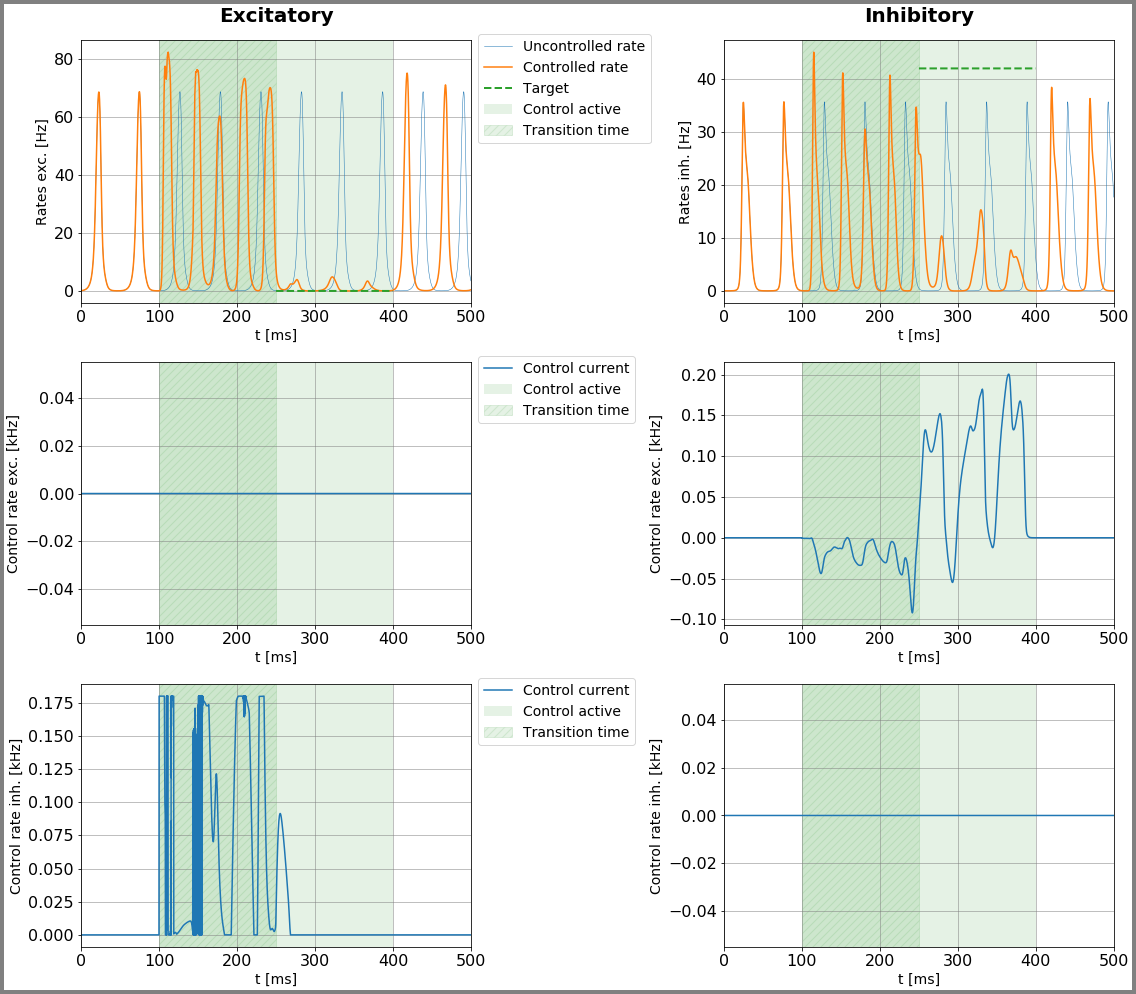

In [22]:
case_ind = 10
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 12

set cost params
control input:  [0, 1, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40765.013021201754
RUN  1 , total integrated cost =  1.4774131911389996e-17
RUN  2 , total integrated cost =  1.477410072047231e-17
RUN  3 , total integrated cost =  1.4748343638478033e-17


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  1.4748343638478033e-17
Control only changes marginally.
RUN  4 , total integrated cost =  1.4748343638478033e-17
Improved over  4  iterations by  100.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.25632976272693


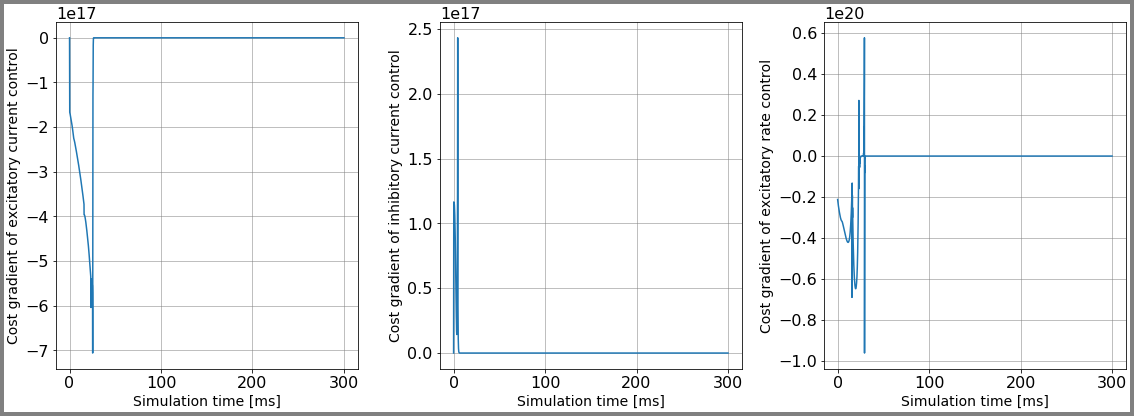

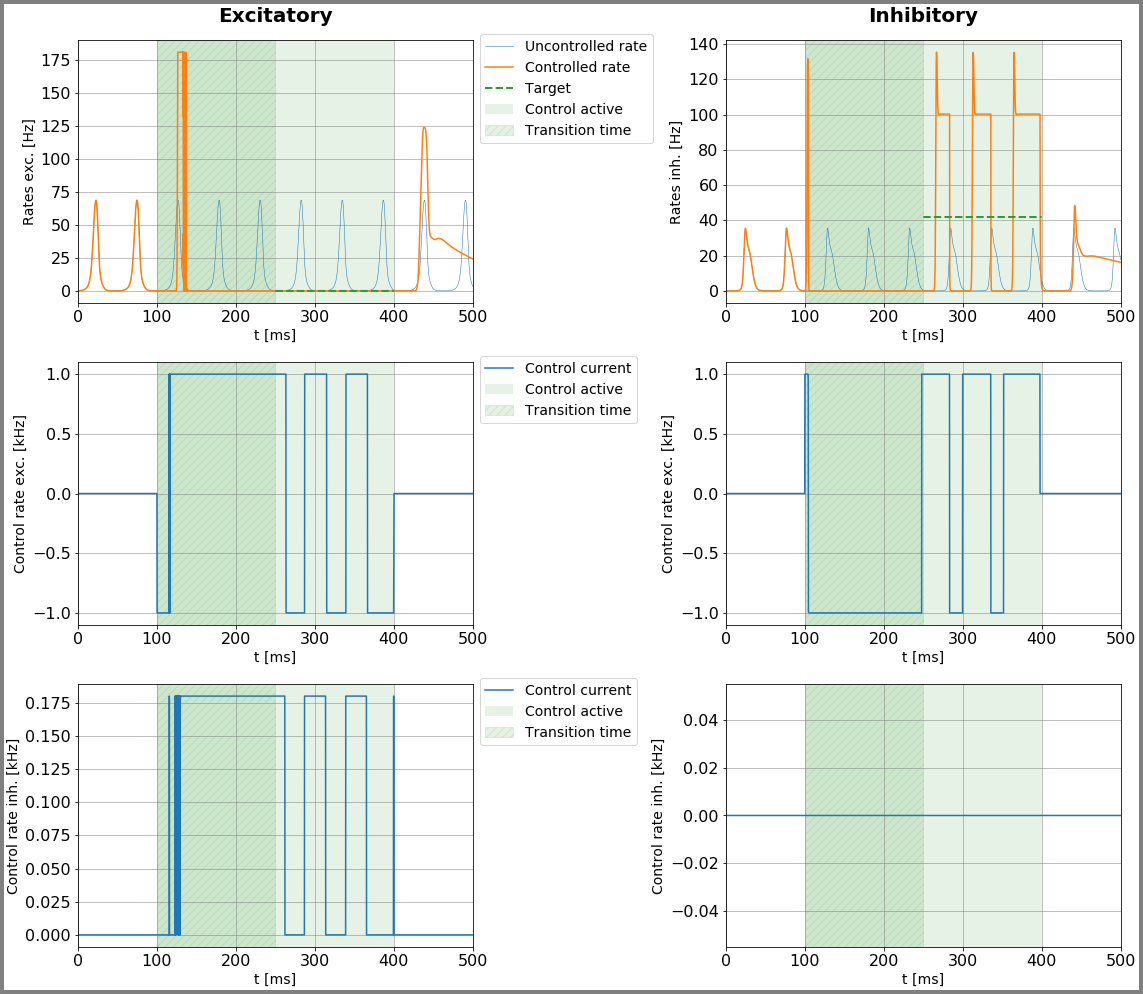

In [23]:
# A.12.a)
case_ind = 12
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  40765.013021201754
RUN  1 , total integrated cost =  10751.430688014934
RUN  2 , total integrated cost =  3732.0146667867084
RUN  3 , total integrated cost =  2838.0947354401615
RUN  4 , total integrated cost =  2522.548613220426
RUN  5 , total integrated cost =  1804.180272715622
RUN  6 , total integrated cost =  1692.1477401035677
RUN  7 , total integrated cost =  1446.3749564363218
RUN  8 , total integrated cost =  1384.0242927782217
RUN  9 , total integrated cost =  1324.6418732319637
RUN  10 , total integrated cost =  1290.9700185519318
RUN  11 , total integrated cost =  1249.1233783482649
RUN  12 , total integrated cost =  1158.5955614288805
RUN  13 , total integrated cost =  1135.3228965073451
RUN  14 , total integrated cost =  1116.7818558049892
RUN  15 , total integrated cost =  1105.7060064206062
RUN  16 , total integrated cost =  1095.8330875113381
RUN  17 , total integrated cost =  1088.

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  3623 , total integrated cost =  492.4345589690718
Improved over  3623  iterations by  98.7920166768671  percent.
Problem in initial value trasfer:  sigmae_f 1.560808398485069 1.5558008294264123
Problem in initial value trasfer:  Vmean_exc -65.28226357221605 -65.25578578379118
Problem in initial value trasfer:  tau_exc 19.346655582108767 19.39454561942365
Problem in initial value trasfer:  Vmean_exc -58.68299461103112 -58.906205014139985


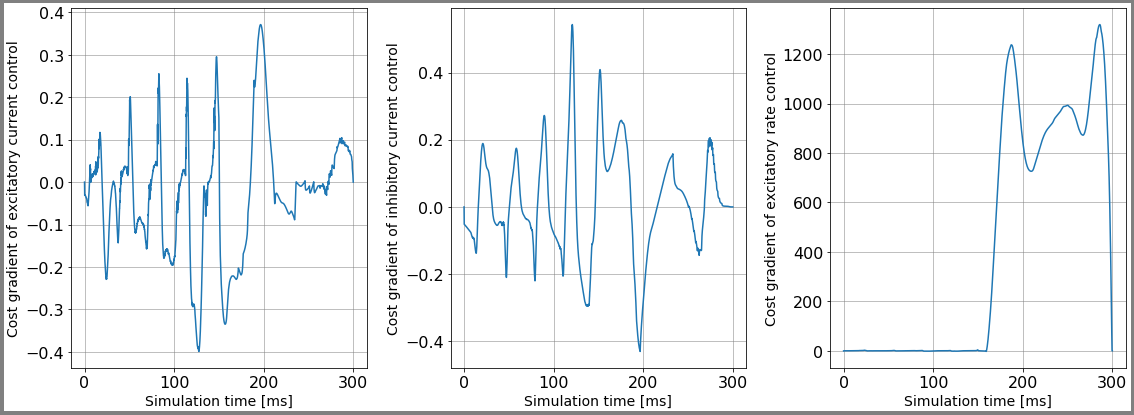

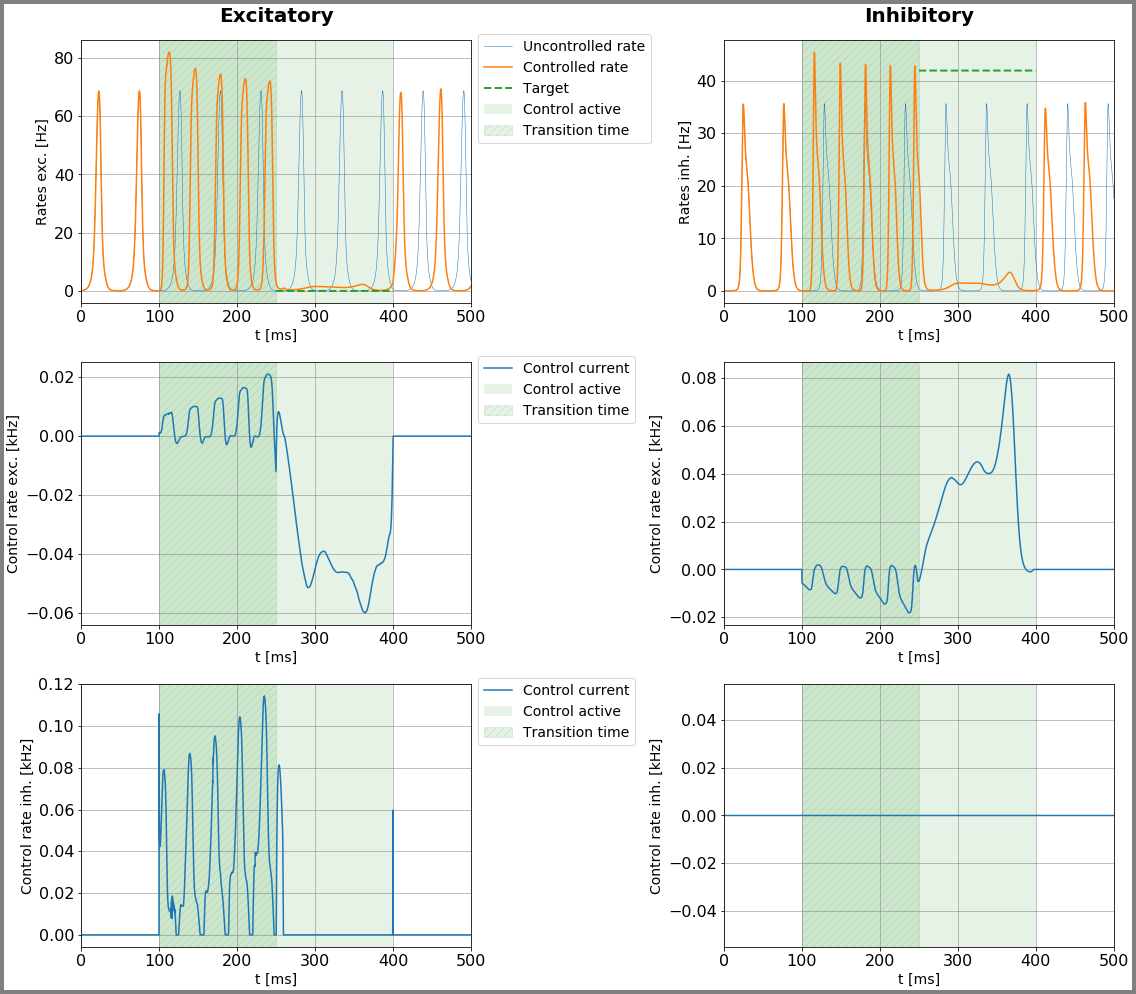

In [24]:
case_ind = 12
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )